# Train XGBoost model (t+1 target)
Train an XGBoost classifier on `data/processed/xgboost_t1`, using `target_t+1` as the label and all columns except the target, `client_nr`, and `yearmonth` as features.

Hyperparameters are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve against the business objective.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import train_xgboost
from train_xgboost import (
    evaluate_all_splits,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

HORIZON = "t1"
train_xgboost.set_horizon(HORIZON)
TARGET_COLUMN = train_xgboost.TARGET_COLUMN

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset xgboost_t1 with target 'target_t+1'


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,835
Validation observations: 3,790
Number of features: 30

Class distribution in training data:
  Negative: 17,507
  Positive: 1,328
  scale_pos_weight: 13.18


Best trial: 9. Best value: 0.17186: 100%|██████████| 50/50 [00:20<00:00,  2.50it/s]



Best validation PR-AUC: 0.1719
Best hyperparameters:
  learning_rate: 0.1
  max_depth: 4
  min_child_weight: 50
  subsample: 0.85
  colsample_bytree: 0.7
  gamma: 0.5
  reg_alpha: 0.01
  reg_lambda: 5
  scale_pos_weight: 13.182981927710843


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
45,45,0.171860,2026-08-31 00:14:25.818359,2026-08-31 00:14:26.173239,0 days 00:00:00.354880,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
9,9,0.171860,2026-08-31 00:14:10.868467,2026-08-31 00:14:11.202090,0 days 00:00:00.333623,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
14,14,0.171860,2026-08-31 00:14:12.523904,2026-08-31 00:14:12.879671,0 days 00:00:00.355767,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
37,37,0.170768,2026-08-31 00:14:21.490110,2026-08-31 00:14:22.290031,0 days 00:00:00.799921,0.7,1.0,0.1,4,20,0.01,25,1.00,COMPLETE
22,22,0.170486,2026-08-31 00:14:15.526343,2026-08-31 00:14:15.948290,0 days 00:00:00.421947,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
17,17,0.170486,2026-08-31 00:14:13.447534,2026-08-31 00:14:13.907087,0 days 00:00:00.459553,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
33,33,0.170486,2026-08-31 00:14:20.011950,2026-08-31 00:14:20.428601,0 days 00:00:00.416651,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
32,32,0.170486,2026-08-31 00:14:19.594960,2026-08-31 00:14:20.008928,0 days 00:00:00.413968,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
31,31,0.170486,2026-08-31 00:14:19.069222,2026-08-31 00:14:19.592614,0 days 00:00:00.523392,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
26,26,0.170486,2026-08-31 00:14:17.061872,2026-08-31 00:14:17.462997,0 days 00:00:00.401125,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

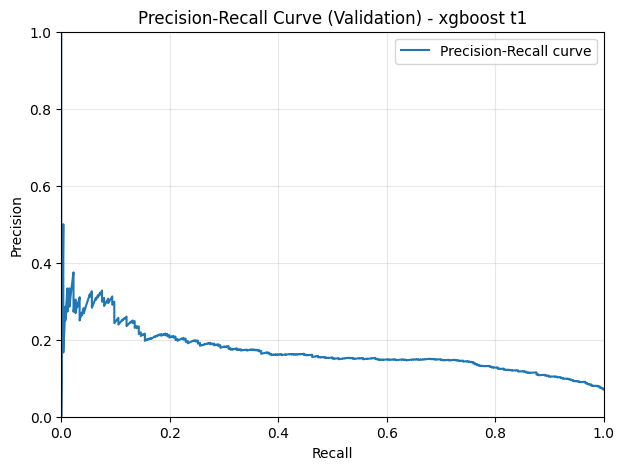

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title=f"Precision-Recall Curve (Validation) - xgboost {HORIZON}",
)

In [5]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.35].head(20)

,threshold,precision,recall
3752,0.796134,0.352941,0.022556
3753,0.796437,0.375000,0.022556
3767,0.818232,0.500000,0.003759


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

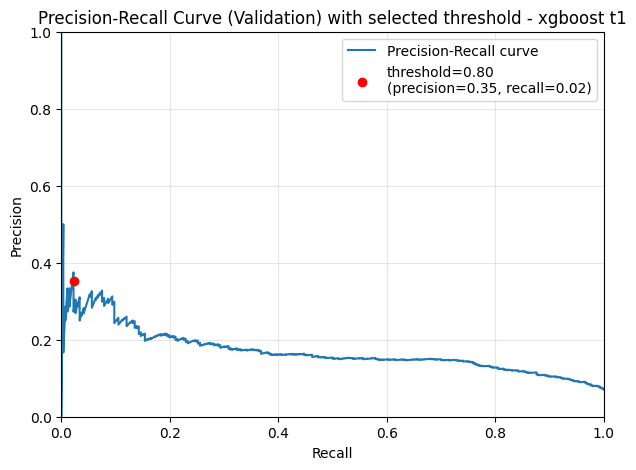

In [9]:
SELECTED_THRESHOLD = 0.796134

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title=f"Precision-Recall Curve (Validation) with selected threshold - xgboost {HORIZON}",
);

## Final evaluation

In [10]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.222557,0.400000,0.013554,0.026220,0.433333,0.029367
val,0.171860,0.375000,0.022556,0.042553,0.288889,0.097744
test,0.146609,0.245283,0.034946,0.061176,0.222222,0.053763


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [11]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\xgboost_t1.joblib


WindowsPath('C:/Users/SVisbee/Repos/Credit_prediction_case/models/artifacts/xgboost_t1.joblib')